In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

from scipy.stats import shapiro, ttest_ind, mannwhitneyu, levene
import scipy.stats as stats
import statsmodels.stats.api as sms


from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter(action='ignore', category=FutureWarning)

pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:.4f}'.format

### 1. Data Overview

In [3]:
import gdown
import pandas as pd
import numpy as np
import io

def load_from_drive(file_id, file_type, info=True):
    # Build the Google Drive download URL
    download_url = f'https://drive.google.com/uc?id={file_id}'

    # Set the local filename for the downloaded file
    output = f'downloaded_file.{file_type}'

    # Download the file
    gdown.download(download_url, output, quiet=False)

    # Read the file based on its type
    if file_type == 'csv':
        read = pd.read_csv(output)  # Read CSV file
    elif file_type == 'xlsx':
        read = pd.read_excel(output)  # Read Excel file
    else:
        raise ValueError("Unsupported file type. Please use 'csv' or 'xlsx'.")

    # Print data information (optional)
    if info:
        if len(read) > 0:
            print("# Data successfully loaded!")
            print("# ------------------------------------", "\n")

            # Print dataset dimensions
            print("# Dimensions -------------------------")
            print("Number of observations:", read.shape[0], " Number of columns:", read.shape[1], "\n")

            # Print data type information
            print("# Data types -----------------------------")
            if len(read.select_dtypes("object").columns) > 0:
                print("Object variables:", "\n", "Count:",
                      len(read.select_dtypes("object").columns), "\n",
                      read.select_dtypes("object").columns.tolist(), "\n")

            if len(read.select_dtypes("int64").columns) > 0:
                print("Integer variables:", "\n", "Count:",
                      len(read.select_dtypes("int64").columns), "\n",
                      read.select_dtypes("int64").columns.tolist(), "\n")

            if len(read.select_dtypes("float64").columns) > 0:
                print("Float variables:", "\n", "Count:",
                      len(read.select_dtypes("float64").columns), "\n",
                      read.select_dtypes("float64").columns.tolist(), "\n")

            if len(read.select_dtypes("bool").columns) > 0:
                print("Boolean variables:", "\n", "Count:",
                      len(read.select_dtypes("bool").columns), "\n",
                      read.select_dtypes("bool").columns.tolist(), "\n")

            # Print missing value information
            print("# Missing values ---------------------")
            print("Are there any missing values?\n ",
                  np.where(read.isnull().values.any() == False,
                           "No missing values detected!",
                           "Dataset contains missing values!"), "\n")

            # Print memory usage
            buf = io.StringIO()
            read.info(buf=buf)
            info_str = buf.getvalue().split('\n')[-2].split(":")[1].strip()
            print("# Memory usage ---------------------- \n", info_str)

        else:
            print("# Data not loaded!")

    return read



In [4]:
file_id = '1aDmGlwFePWC9upjR_fpfTpqgns9SzP0i'
file_type = 'csv'
ab = load_from_drive(file_id, file_type)
ab.head()

Downloading...
From: https://drive.google.com/uc?id=1aDmGlwFePWC9upjR_fpfTpqgns9SzP0i
To: /content/downloaded_file.csv
100%|██████████| 2.80M/2.80M [00:00<00:00, 32.4MB/s]


# Data successfully loaded!
# ------------------------------------ 

# Dimensions -------------------------
Number of observations: 90189  Number of columns: 5 

# Data types -----------------------------
Object variables: 
 Count: 1 
 ['version'] 

Integer variables: 
 Count: 2 
 ['userid', 'sum_gamerounds'] 

Boolean variables: 
 Count: 2 
 ['retention_1', 'retention_7'] 

# Missing values ---------------------
Are there any missing values?
  No missing values detected! 

# Memory usage ---------------------- 
 2.2+ MB


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [5]:
ab.rename(columns={'sum_gamerounds':'gamerounds_7d'}, inplace=True)

In [6]:
ab['version'] = ab['version'].map({"gate_30":"A", "gate_40":'B'})

In [7]:
# Number of unique player
ab["userid"].nunique()

90189

In [8]:
# Counting the number of players in each A/B group.
ab.groupby(["version"])[["userid"]].nunique()

,userid
version,
A,44700
B,45489


In [9]:
ab['version'].value_counts()

,count
version,
B,45489
A,44700


In [10]:
# Check if userid is unique
print(ab.userid.nunique() == ab.shape[0])

#  Display statistic summary of gamerounds_7d
ab.describe([0.01, 0.05, 0.10, 0.20, 0.80, 0.90, 0.95, 0.99])[["gamerounds_7d"]].T

True


,count,mean,std,min,1%,5%,10%,20%,50%,80%,90%,95%,99%,max
gamerounds_7d,90189.0000,51.8725,195.0509,0.0000,0.0000,1.0000,1.0000,3.0000,16.0000,67.0000,134.0000,221.0000,493.0000,49854.0000


In [11]:
# Display statistic summary of gamerounds_7d for each group
ab.groupby("version")["gamerounds_7d"].agg(["count", "median", "mean", "std", "max"])

,count,median,mean,std,max
version,,,,,
A,44700,17.0000,52.4563,256.7164,49854
B,45489,16.0000,51.2988,103.2944,2640


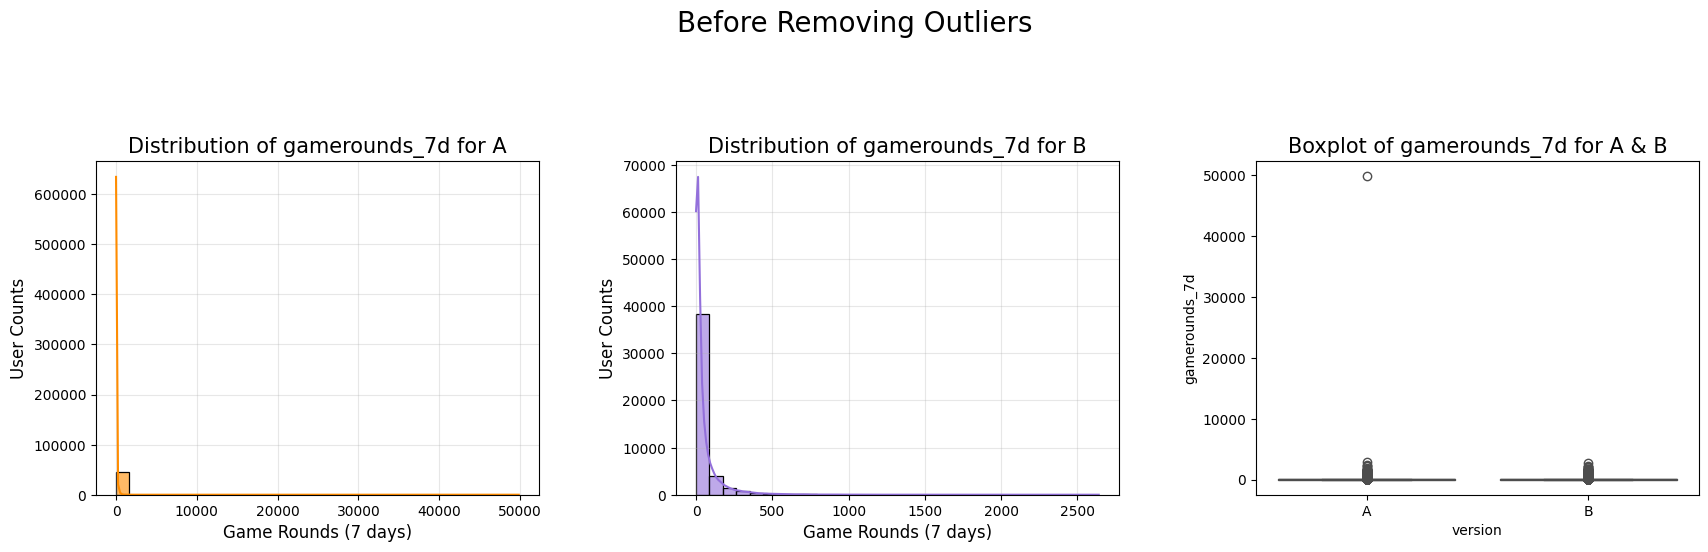

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Histogram + KDE for A
sns.histplot(
    data=ab[ab.version == "A"],
    x="gamerounds_7d",
    ax=axes[0],
    color="darkorange",
    bins=30,
    kde=True,
    alpha=0.6
)

# Histogram + KDE for B
sns.histplot(
    data=ab[ab.version == "B"],
    x="gamerounds_7d",
    ax=axes[1],
    color="mediumpurple",
    bins=30,
    kde=True,
    alpha=0.6
)

# Boxplot for A & B
sns.boxplot(
    data=ab,
    x="version",
    y="gamerounds_7d",
    ax=axes[2],
    palette=["darkorange", "mediumpurple"]
)

# Titles
plt.suptitle("Before Removing Outliers", fontsize=20)
axes[0].set_title("Distribution of gamerounds_7d for A", fontsize=15)
axes[1].set_title("Distribution of gamerounds_7d for B", fontsize=15)
axes[2].set_title("Boxplot of gamerounds_7d for A & B", fontsize=15)

# Axis labels
for ax in axes[:2]:
    ax.set_xlabel("Game Rounds (7 days)", fontsize=12)
    ax.set_ylabel("User Counts", fontsize=12)
    ax.grid(alpha=0.3)

plt.tight_layout(pad=4)
plt.show()


In [14]:
# Calculating 1-day and 7-days retention for each group
ab.groupby("version").agg(
    user_count=("userid", "count"),
    day_1_retention=("retention_1", "mean"),
    day_7_retention=("retention_7", "mean"),
    sum_gamerounds_7d=("gamerounds_7d", "sum")
)

,user_count,day_1_retention,day_7_retention,sum_gamerounds_7d
version,,,,
A,44700,0.4482,0.1902,2344795
B,45489,0.4423,0.1820,2333530


### 2. Data Clean

In [15]:
# Remove outliers
ab = ab[ab.gamerounds_7d < ab.gamerounds_7d.max()]


ab.describe([0.01, 0.05, 0.10, 0.20, 0.80, 0.90, 0.95, 0.99])[["gamerounds_7d"]].T

,count,mean,std,min,1%,5%,10%,20%,50%,80%,90%,95%,99%,max
gamerounds_7d,90188.0000,51.3203,102.6827,0.0000,0.0000,1.0000,1.0000,3.0000,16.0000,67.0000,134.0000,221.0000,493.0000,2961.0000


In [16]:
# Display statistic summary of gamerounds_7d for each group
ab.groupby("version").gamerounds_7d.agg(["count", "median", "mean", "std", "max"])

,count,median,mean,std,max
version,,,,,
A,44699,17.0000,51.3421,102.0576,2961
B,45489,16.0000,51.2988,103.2944,2640


In [17]:
# Calculating 1-day and 7-days retention for each group
ab.groupby("version").agg(
    user_count=("userid", "count"),
    day_1_retention=("retention_1", "mean"),
    day_7_retention=("retention_7", "mean"),
    sum_gamerounds_7d=("gamerounds_7d", "sum")
)

,user_count,day_1_retention,day_7_retention,sum_gamerounds_7d
version,,,,
A,44699,0.4482,0.1902,2294941
B,45489,0.4423,0.1820,2333530


### 3. EDA

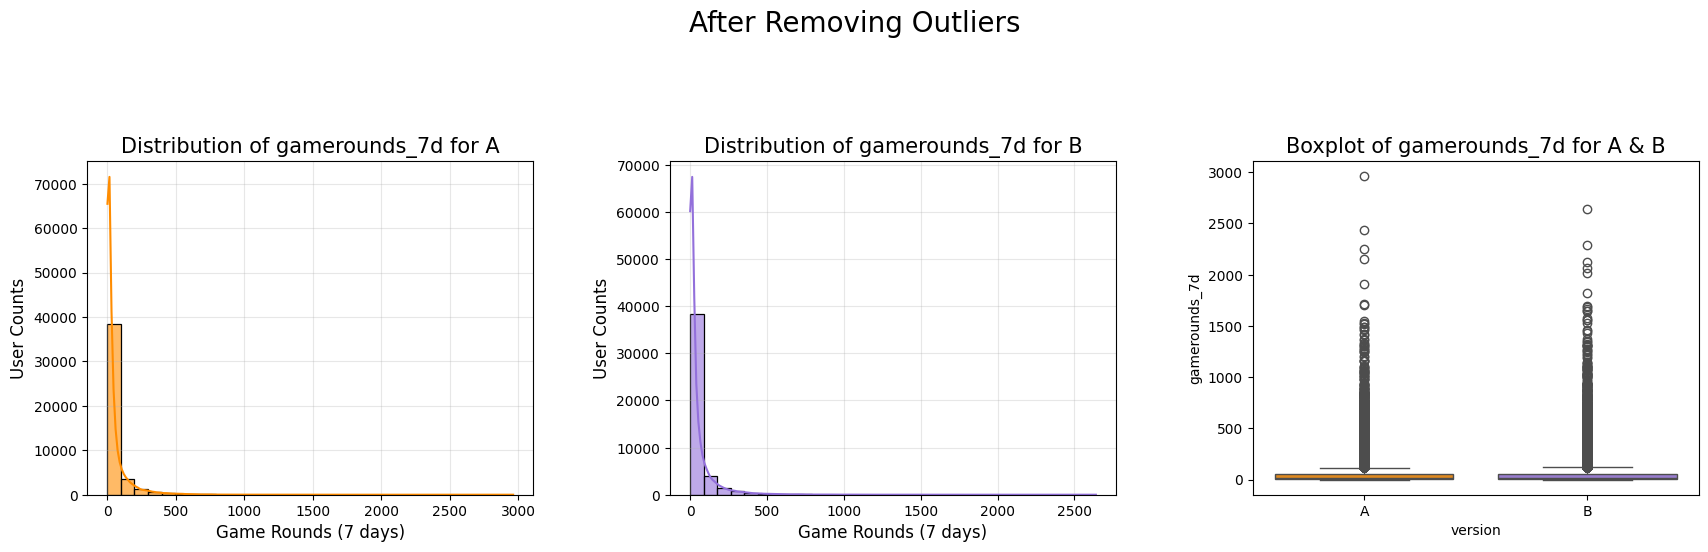

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Histogram + KDE for A
sns.histplot(
    data=ab[ab.version == "A"],
    x="gamerounds_7d",
    ax=axes[0],
    color="darkorange",
    bins=30,
    kde=True,
    alpha=0.6
)

# Histogram + KDE for B
sns.histplot(
    data=ab[ab.version == "B"],
    x="gamerounds_7d",
    ax=axes[1],
    color="mediumpurple",
    bins=30,
    kde=True,
    alpha=0.6
)

# Boxplot for A & B
sns.boxplot(
    data=ab,
    x="version",
    y="gamerounds_7d",
    ax=axes[2],
    palette=["darkorange", "mediumpurple"]
)

# Titles
plt.suptitle("After Removing Outliers", fontsize=20)
axes[0].set_title("Distribution of gamerounds_7d for A", fontsize=15)
axes[1].set_title("Distribution of gamerounds_7d for B", fontsize=15)
axes[2].set_title("Boxplot of gamerounds_7d for A & B", fontsize=15)

# Axis labels
for ax in axes[:2]:
    ax.set_xlabel("Game Rounds (7 days)", fontsize=12)
    ax.set_ylabel("User Counts", fontsize=12)
    ax.grid(alpha=0.3)

plt.tight_layout(pad=4)
plt.show()


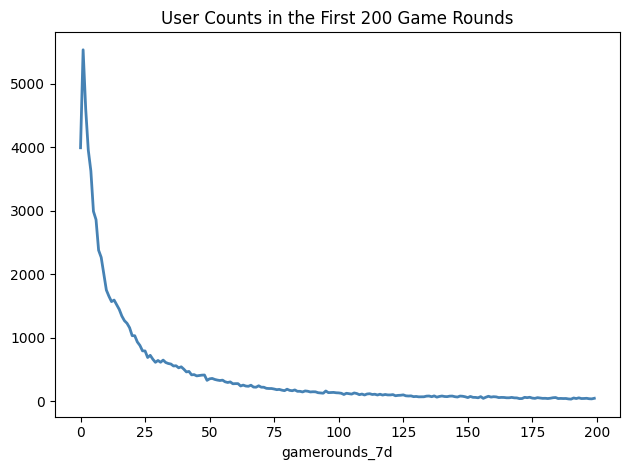

In [19]:
ab.groupby("gamerounds_7d").userid.count()[:200].plot(
    kind="line", color="steelblue", linewidth=2
)

plt.title("User Counts in the First 200 Game Rounds", fontsize=12)
plt.tight_layout()
plt.show()



In [42]:
#  User proportion in Group A and Group B who reached gamerounds_7d >= 30
rate_A = (ab[ab['version'] == 'A']['gamerounds_7d'] >= 30).mean()
rate_B = (ab[ab['version'] == 'B']['gamerounds_7d'] >= 30).mean()

print(f"Proportion (A) = {rate_A:.3%}")
print(f"Proportion (B) = {rate_B:.3%}")


Proportion (A) = 37.260%
Proportion (B) = 36.521%


In [21]:
# Retention information
pd.DataFrame({
    "retention_1_count": ab["retention_1"].value_counts(),
    "retention_1_ratio": ab["retention_1"].value_counts() / len(ab),
    "retention_7_count": ab["retention_7"].value_counts(),
    "retention_7_ratio": ab["retention_7"].value_counts() / len(ab)
})

,retention_1_count,retention_1_ratio,retention_7_count,retention_7_ratio
False,50035,0.5548,73408,0.8139
True,40153,0.4452,16780,0.1861


In [22]:
ab.groupby(["version", "retention_1"]).gamerounds_7d.agg(["count", "median", "mean", "std", "max"])

count  median    mean      std   max
version retention_1                                      
A       False        24665  6.0000 16.3591  36.5284  1072
        True         20034 48.0000 94.4117 135.0377  2961
B       False        25370  6.0000 16.3404  35.9258  1241
        True         20119 49.0000 95.3812 137.8873  2640

In [23]:
ab.groupby(["version", "retention_7"]).gamerounds_7d.agg(["count", "median", "mean", "std", "max"])

count   median     mean      std   max
version retention_7                                        
A       False        36198  11.0000  25.7965  43.3162   981
        True          8501 105.0000 160.1175 179.3586  2961
B       False        37210  11.0000  25.8564  44.4061  2640
        True          8279 111.0000 165.6498 183.7925  2294

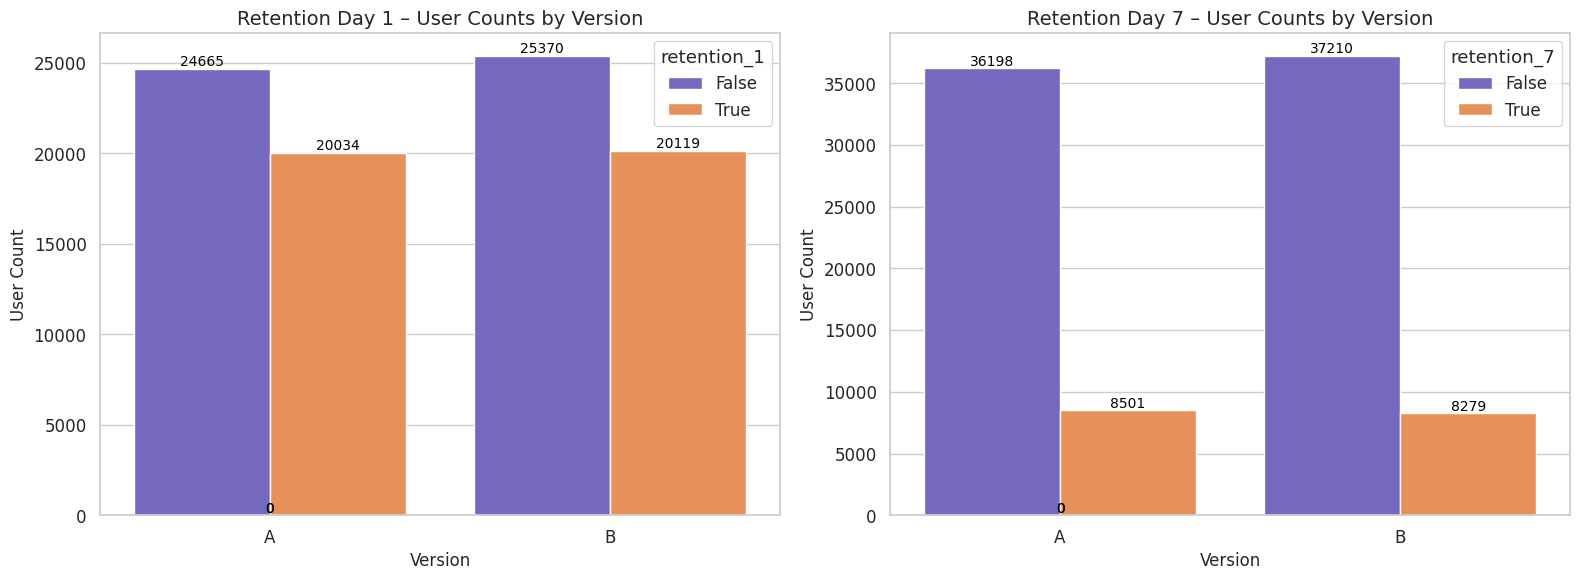

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate descriptive statistics by version and retention_1 status
stats1 = (
    ab.groupby(["version", "retention_1"])
      .gamerounds_7d
      .agg(["count", "median", "mean", "std", "max"])
      .reset_index()
)

sns.set(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(16, 6))

# ---- Subplot 1: Retention Day 1 ----
plt.subplot(1, 2, 1)
palette1 = {0: "#6A5ACD", 1: "#FF8C42"}
ax1 = sns.barplot(data=stats1, x='version', y='count', hue='retention_1', palette=palette1)
plt.title('Retention Day 1 – User Counts by Version', fontsize=14)
plt.xlabel('Version', fontsize=12)
plt.ylabel('User Count', fontsize=12)

# Add value annotations
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', fontsize=10, color='black',
                 xytext=(0, 5), textcoords='offset points')

# ---- Calculate descriptive statistics by version and retention_7 ----
stats7 = (
    ab.groupby(["version", "retention_7"])
      .gamerounds_7d
      .agg(["count", "median", "mean", "std", "max"])
      .reset_index()
)

# ---- Subplot 2: Retention Day 7 ----
plt.subplot(1, 2, 2)
palette2 = {0: "#6A5ACD", 1: "#FF8C42"}
ax2 = sns.barplot(data=stats7, x='version', y='count', hue='retention_7', palette=palette2)
plt.title('Retention Day 7 – User Counts by Version', fontsize=14)
plt.xlabel('Version', fontsize=12)
plt.ylabel('User Count', fontsize=12)

# Add value annotations
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height())}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', fontsize=10, color='black',
                 xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()


In [28]:
ab["Retention"] = np.where((ab.retention_1 == True) & (ab.retention_7 == True), 1,0)
ab.groupby(["version", "Retention"])["gamerounds_7d"].agg(["count", "median", "mean", "std", "max"])

count   median     mean      std   max
version Retention                                        
A       0          38023  12.0000  28.0703  48.0175  1072
        1           6676 127.0000 183.8863 189.6264  2961
B       0          38983  12.0000  28.1034  48.9278  2640
        1           6506 133.0000 190.2824 194.2201  2294

### 4. Hypothesis Test - Numeric Metrics


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, levene
import statsmodels.stats.api as sms

def AB_Test(dataframe, group, target, alpha=0.05, visualize=True):
    """
    Perform an A/B test to compare two groups on a numeric target variable.
    Automatically chooses between parametric (t-test) and non-parametric (Mann–Whitney U) methods
    based on normality and homogeneity of variances.

    """

    # Split A/B groups
    groupA = dataframe[dataframe[group] == "A"][target]
    groupB = dataframe[dataframe[group] == "B"][target]

    # Normality test (Shapiro–Wilk)
    ntA = shapiro(groupA)[1] < alpha
    ntB = shapiro(groupB)[1] < alpha

    # Homogeneity of variance test (Levene’s test)
    leveneTest = levene(groupA, groupB)[1] < alpha

    # Select test type based on normality and variance homogeneity
    if (ntA == False) & (ntB == False):  # both normal
        if leveneTest == False:
            ttest, p_value = ttest_ind(groupA, groupB, equal_var=True)
            test_type = "Parametric (Equal Variance)"
        else:
            ttest, p_value = ttest_ind(groupA, groupB, equal_var=False)
            test_type = "Parametric (Unequal Variance)"
    else:
        ttest, p_value = mannwhitneyu(groupA, groupB, alternative='two-sided')
        test_type = "Non-Parametric (Mann–Whitney U)"

    # Compute mean difference
    mean_diff = groupB.mean() - groupA.mean()

    # Compute effect size (Cohen’s d)
    nobs_A = len(groupA)
    nobs_B = len(groupB)
    pooled_std = np.sqrt(((nobs_A - 1) * groupA.var() + (nobs_B - 1) * groupB.var()) / (nobs_A + nobs_B - 2))
    effect_size = mean_diff / pooled_std

    # Compute observed power
    observed_power = sms.tt_ind_solve_power(
        effect_size=effect_size, nobs1=nobs_A, alpha=alpha, alternative='two-sided'
    )

    # Hypothesis result
    ab_hypothesis = p_value < alpha
    comment = "No significant difference between A and B." if not ab_hypothesis else "Significant difference between A and B!"

    # Summarize results
    result = pd.DataFrame({
        "Test Type": [test_type],
        "Target Variable": [target],
        "Equal Variance (Levene)": ["Yes" if not leveneTest else "No"],
        "Hypothesis Result": ["Reject H0" if ab_hypothesis else "Fail to Reject H0"],
        "p-value": [p_value],
        "Mean Difference": [mean_diff],
        "Effect Size (Cohen's d)": [effect_size],
        "Observed Power": [observed_power],
        "Comment": [comment],
        "t-statistic": [ttest]
    })

    # Print hypotheses
    print("# A/B Test Hypotheses")
    print("H0: Mean(A) = Mean(B)")
    print("H1: Mean(A) ≠ Mean(B)\n")

    # Print assumption checks
    print(f"Normality check:\nA group: {not ntA},  B group: {not ntB}\n")
    print(f"Equal variance (Levene’s test): {not leveneTest}\n")

    # Visualization
    if visualize:
        plt.figure(figsize=(6, 4))
        sns.histplot(data=dataframe, x=target, hue=group, kde=True, palette=["#4C72B0", "#DD8452"])
        plt.axvline(groupA.mean(), color='blue', linestyle='dashed', linewidth=2, label=f'Mean A: {groupA.mean():.2f}')
        plt.axvline(groupB.mean(), color='orange', linestyle='dashed', linewidth=2, label=f'Mean B: {groupB.mean():.2f}')
        plt.title('Distribution of Groups', fontsize=14)
        plt.xlabel(target)
        plt.ylabel('Frequency')
        plt.legend()
        plt.tight_layout()
        plt.show()

    return result



# A/B Test Hypotheses
H0: Mean(A) = Mean(B)
H1: Mean(A) ≠ Mean(B)

Normality check:
A group: False,  B group: False

Equal variance (Levene’s test): True



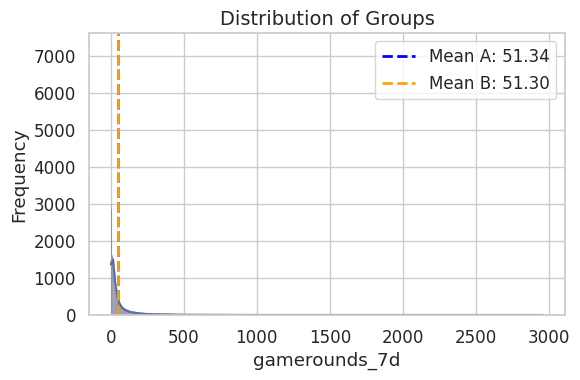

,Test Type,Target Variable,Equal Variance (Levene),Hypothesis Result,p-value,Mean Difference,Effect Size (Cohen's d),Observed Power,Comment,t-statistic
0,Non-Parametric (Mann–Whitney U),gamerounds_7d,Yes,Fail to Reject H0,0.0509,-0.0433,-0.0004,0.0505,No significant difference between A and B.,1024285761.5000


In [30]:
result = AB_Test(dataframe=ab, group="version", target="gamerounds_7d")

result

### 5. Hypothesis Test - Proportion Metrics

In [31]:
df = ab.copy()

In [32]:
df

,userid,version,gamerounds_7d,retention_1,retention_7,Retention
0,116,A,3,False,False,0
1,337,A,38,True,False,0
2,377,B,165,True,False,0
3,483,B,1,False,False,0
4,488,B,179,True,True,1
...,...,...,...,...,...,...
90184,9999441,B,97,True,False,0
90185,9999479,B,30,False,False,0
90186,9999710,A,28,True,False,0
90187,9999768,B,51,True,False,0


In [ ]:
def proportion_ztest(df, version_col, metric_col, alpha=0.05):
    from statsmodels.stats.proportion import proportions_ztest

    counts = np.array([
        df[df[version_col] == "A"][metric_col].sum(),
        df[df[version_col] == "B"][metric_col].sum()
    ])
    nobs = np.array([
        df[df[version_col] == "A"].shape[0],
        df[df[version_col] == "B"].shape[0]
    ])

    z, p = proportions_ztest(counts, nobs, alternative="two-sided")
    sig = "Significant" if p < alpha else "Not Significant"
    print(f"{metric_col}: z = {z:.3f}, p = {p:.4f} → {sig}")
    return z, p


In [35]:
proportion_ztest(df, "version", "retention_1")

retention_1: z = 1.787, p = 0.0739 → Not Significant


(np.float64(1.787103509763628), np.float64(0.0739207603418346))

In [36]:
proportion_ztest(df, "version", "retention_7")

retention_7: z = 3.157, p = 0.0016 → Significant


(np.float64(3.1574100858819936), np.float64(0.0015917731773993442))

In [38]:
def proportion_ztest_2(df, version_col, gamerounds_col, rounds, metric_col, alpha=0.05):
    from statsmodels.stats.proportion import proportions_ztest

    counts = np.array([
        df[(df[version_col] == "A") & (df[gamerounds_col] >= rounds)][metric_col].count(),
        df[(df[version_col] == "B") & (df[gamerounds_col] >= rounds)][metric_col].count()
    ])
    nobs = np.array([
        df[df[version_col] == "A"].shape[0],
        df[df[version_col] == "B"].shape[0]
    ])

    z, p = proportions_ztest(counts, nobs, alternative="two-sided")
    sig = "Significant" if p < alpha else "Not Significant"
    print(f"Users with {gamerounds_col} ≥ {rounds}: z = {z:.3f}, p = {p:.4f} → {sig}")
    return z, p



In [39]:
proportion_ztest_2(df, "version", "gamerounds_7d", 30, "userid")

Users with gamerounds_7d ≥ 30: z = 2.301, p = 0.0214 → Significant


(np.float64(2.3010410893152327), np.float64(0.021389308661310114))

### 6. Bootstrapping

100%|██████████| 500/500 [00:09<00:00, 50.34it/s]


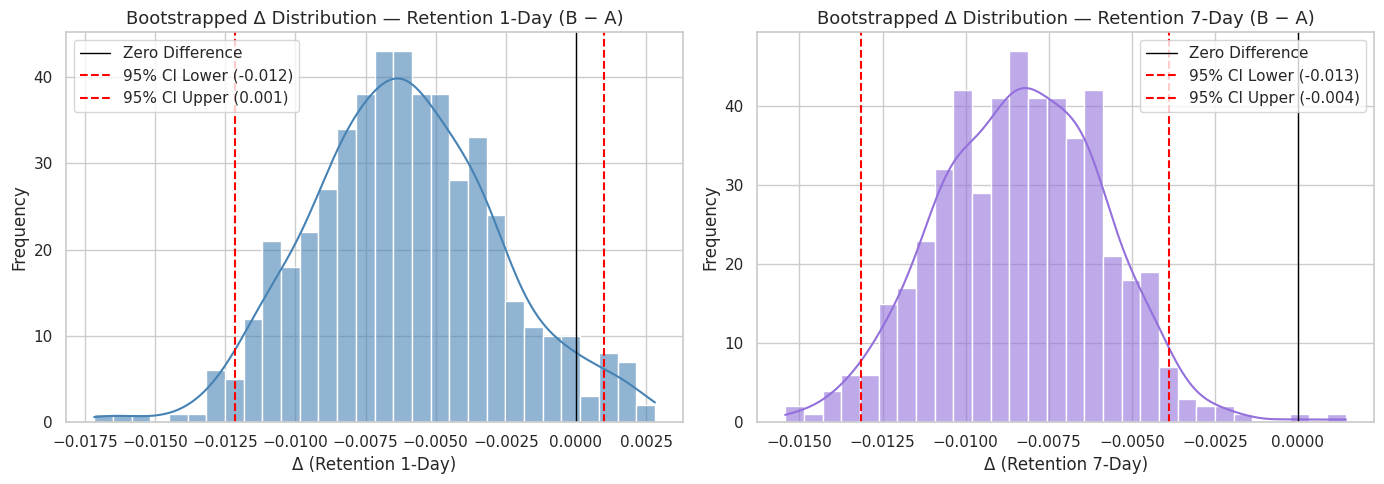

Retention 1-Day
Mean Δ (B − A): -0.0060
95% CI: -0.0122 — 0.0010
→ Not significant.

Retention 7-Day
Mean Δ (B − A): -0.0082
95% CI: -0.0131 — -0.0039
→ Significant difference.


In [62]:
from tqdm import tqdm
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------
# Bootstrap setup
# -------------------------------
iterations = 500
bootstrap_records = []
bootstrap_deltas_1d = []
bootstrap_deltas_7d = []

df = ab.copy()

for i in tqdm(range(iterations)):
    # 1️⃣ Resample with replacement
    sample_df = df.sample(frac=1, replace=True)

    # 2️⃣ Compute mean retention per version
    iter_result = (
        sample_df.groupby("version", as_index=False)
                 .agg(
                     retention_1_mean=("retention_1", "mean"),
                     retention_7_mean=("retention_7", "mean")
                 )
    )

    # 3️⃣ Extract A/B means
    r1_A = iter_result.loc[iter_result["version"] == "A", "retention_1_mean"].values[0]
    r1_B = iter_result.loc[iter_result["version"] == "B", "retention_1_mean"].values[0]
    r7_A = iter_result.loc[iter_result["version"] == "A", "retention_7_mean"].values[0]
    r7_B = iter_result.loc[iter_result["version"] == "B", "retention_7_mean"].values[0]

    delta_1 = r1_B - r1_A
    delta_7 = r7_B - r7_A

    # 4️⃣ Store results
    bootstrap_records.extend([
        {"iteration": i, "version": "A", "retention_1": r1_A, "retention_7": r7_A},
        {"iteration": i, "version": "B", "retention_1": r1_B, "retention_7": r7_B}
    ])
    bootstrap_deltas_1d.append(delta_1)
    bootstrap_deltas_7d.append(delta_7)

# Convert to DataFrames
bootstrap_rates = pd.DataFrame(bootstrap_records)
bootstrap_df_1d = pd.DataFrame(bootstrap_deltas_1d, columns=["delta_1d"])
bootstrap_df_7d = pd.DataFrame(bootstrap_deltas_7d, columns=["delta_7d"])

# -------------------------------
# Compute summary statistics
# -------------------------------

ci_1d_lower, ci_1d_upper = bootstrap_df_1d["delta_1d"].quantile([0.025, 0.975])
ci_7d_lower, ci_7d_upper = bootstrap_df_7d["delta_7d"].quantile([0.025, 0.975])


# -------------------------------
# Visualization: Delta Distributions
# -------------------------------
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- 1-Day Delta ----
sns.histplot(bootstrap_df_1d["delta_1d"], bins=30, kde=True, color="steelblue", alpha=0.6, ax=axes[0])
axes[0].axvline(0, color="black", linestyle="-", linewidth=1, label="Zero Difference")
axes[0].axvline(ci_1d_lower, color="red", linestyle="--", label=f"95% CI Lower ({ci_1d_lower:.3f})")
axes[0].axvline(ci_1d_upper, color="red", linestyle="--", label=f"95% CI Upper ({ci_1d_upper:.3f})")
axes[0].set_title("Bootstrapped Δ Distribution — Retention 1-Day (B − A)", fontsize=13)
axes[0].set_xlabel("Δ (Retention 1-Day)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# ---- 7-Day Delta ----
sns.histplot(bootstrap_df_7d["delta_7d"], bins=30, kde=True, color="mediumpurple", alpha=0.6, ax=axes[1])
axes[1].axvline(0, color="black", linestyle="-", linewidth=1, label="Zero Difference")
axes[1].axvline(ci_7d_lower, color="red", linestyle="--", label=f"95% CI Lower ({ci_7d_lower:.3f})")
axes[1].axvline(ci_7d_upper, color="red", linestyle="--", label=f"95% CI Upper ({ci_7d_upper:.3f})")
axes[1].set_title("Bootstrapped Δ Distribution — Retention 7-Day (B − A)", fontsize=13)
axes[1].set_xlabel("Δ (Retention 7-Day)")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.show()

# -------------------------------
# Summary Output
# -------------------------------
print("Retention 1-Day")
print(f"Mean Δ (B − A): {mean_1d:.4f}")
print(f"95% CI: {ci_1d_lower:.4f} — {ci_1d_upper:.4f}")
if (ci_1d_lower > 0) or (ci_1d_upper < 0):
    print("→ Significant difference.")
else:
    print("→ Not significant.")

print("\nRetention 7-Day")
print(f"Mean Δ (B − A): {mean_7d:.4f}")
print(f"95% CI: {ci_7d_lower:.4f} — {ci_7d_upper:.4f}")
if (ci_7d_lower > 0) or (ci_7d_upper < 0):
    print("→ Significant difference.")
else:
    print("→ Not significant.")


In [63]:
retention_1_prob = ( bootstrap_df_1d["delta_1d"] < 0).mean()
retention_7_prob = ( bootstrap_df_7d["delta_7d"]< 0).mean()

print('Probability that retention_1 in variant group will be worse than retention_1 in control group is', '{:.2%}.'.format(retention_1_prob))
print('Probability that retention_7 in variant group will be worse than retention_7 in control group is', '{:.2%}.'.format(retention_7_prob))

Probability that retention_1 in variant group will be worse than retention_1 in control group is 95.80%.
Probability that retention_7 in variant group will be worse than retention_7 in control group is 99.80%.


100%|██████████| 500/500 [00:08<00:00, 60.91it/s]


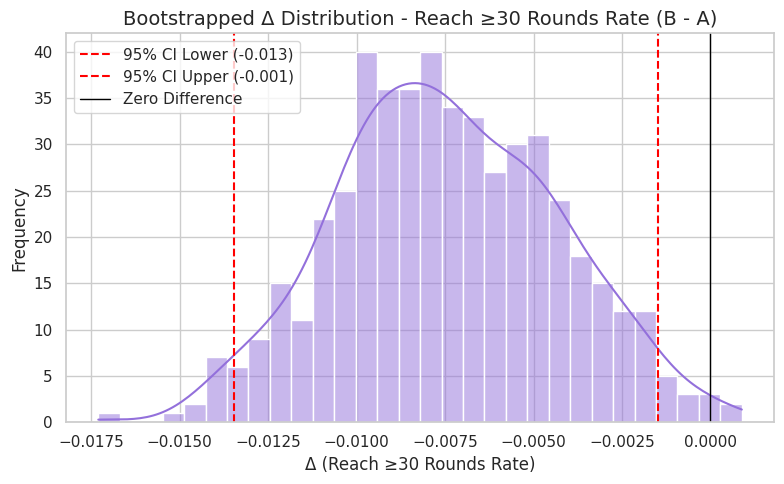

Mean Δ (B - A): -0.0075
95% Confidence Interval: -0.0135 — -0.0015
The difference in 30-round reach rate is statistically significant.


In [68]:
from tqdm import tqdm
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Number of bootstrap iterations
iterations = 500
bootstrap_records = []  # store both A & B rates per iteration
bootstrap_deltas = []   # store only differences

df = ab.copy()

for i in tqdm(range(iterations)):
    # 1️⃣ Resample the dataset (with replacement)
    sample_df = df.sample(frac=1, replace=True)

    # 2️⃣ Compute reach rate (≥30 rounds) for each version
    iter_result = (
        sample_df.groupby('version')['gamerounds_7d']
                 .apply(lambda x: (x >= 30).mean())
                 .reset_index(name='reach_30rounds_rate')
    )

    # 3️⃣ Extract A and B rates
    rate_A = iter_result.loc[iter_result['version'] == 'A', 'reach_30rounds_rate'].values[0]
    rate_B = iter_result.loc[iter_result['version'] == 'B', 'reach_30rounds_rate'].values[0]
    delta = rate_B - rate_A

    # 4️⃣ Record both rates and delta for plotting
    bootstrap_records.append({'iteration': i, 'version': 'A', 'reach_rate': rate_A})
    bootstrap_records.append({'iteration': i, 'version': 'B', 'reach_rate': rate_B})
    bootstrap_deltas.append(delta)

# Convert to DataFrames
bootstrap_df = pd.DataFrame(bootstrap_deltas, columns=['delta'])
bootstrap_rates = pd.DataFrame(bootstrap_records)


# ---- Compute confidence interval for delta ----
ci_lower = bootstrap_df['delta'].quantile(0.025)
ci_upper = bootstrap_df['delta'].quantile(0.975)


# ---- Visualization 2: Delta distribution ----
plt.figure(figsize=(8, 5))
sns.histplot(bootstrap_df['delta'], bins=30, kde=True, color="mediumpurple")
plt.axvline(ci_lower, color='red', linestyle='--', label=f"95% CI Lower ({ci_lower:.3f})")
plt.axvline(ci_upper, color='red', linestyle='--', label=f"95% CI Upper ({ci_upper:.3f})")
plt.axvline(0, color='black', linestyle='-', linewidth=1, label='Zero Difference')

plt.title('Bootstrapped Δ Distribution - Reach ≥30 Rounds Rate (B - A)', fontsize=14)
plt.xlabel('Δ (Reach ≥30 Rounds Rate)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# ---- Print summary results ----
print(f"Mean Δ (B - A): {bootstrap_df['delta'].mean():.4f}")
print(f"95% Confidence Interval: {ci_lower:.4f} — {ci_upper:.4f}")

if (ci_lower > 0) or (ci_upper < 0):
    print("The difference in 30-round reach rate is statistically significant.")
else:
    print("The difference in 30-round reach rate is NOT statistically significant.")


In [69]:
reach_30rounds_prob = (bootstrap_df['delta'] < 0).mean()

print('Probability that reach_30rounds_rate in variant group is worse than the control group is', '{:.2%}.'.format(reach_30rounds_prob))


Probability that reach_30rounds_rate in variant group is worse than the control group is 99.40%.
